**IMPORT & SETUP**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


**LOADING DATASET**

In [2]:

raw_df = pd.read_csv("week_1-3(Sheet1).csv")
raw_df.head(50)


,Date,Max speed,Average Speed,Distance,Travel Time,Stopped Time,Traffic Level,Ride Quality,Backride,Fuel Consumption,Max Alt
0,19-Nov-25,88.3 kph,20.7 kph,43.6 km,117 mins,387 seconds,2,Aggressive,0.50,1.2 L,76 m
1,20-Nov-25,90.3 kph,21.8 kph,39.2 km,101 mins,528 seconds,2,Aggressive,0.50,1.05 L,77 m
2,21-Nov-25,54.3 kph,18.6 kph,44.3 km,135 mins,1130 seconds,3,Slow,0.00,0.94 L,41 m
3,22-Nov-25,89.8 kph,29.4 kph,80.8 km,160 mins,745 seconds,1,Aggressive,1.00,1.96 L,75 m
4,24-Nov-25,56 kph,17 kph,43.4 km,144 mins,934 seconds,2,Slow,0.50,1.12 L,79 m
5,26-Nov-25,88.5 kph,19.8 kph,91.4 km,252 mins,2280 seconds,3,Aggressive,0.50,2.34 L,77 m
6,28-Nov-25,90.3 kph,20.1 kph,49.9 km,135 mins,1500 seconds,3,Aggressive,0.50,1.29 L,77 m
7,29-Nov-25,87.2 kph,20 kph,69.4 km,197 mins,1130 seconds,2,Aggressive,1.00,1.95 L,78 m
8,2-Dec-25,76.7 kph,23.1 kph,45 km,109 mins,1200 seconds,3,Normal,0.00,1 L,45 m
9,3-Dec-25,89.7 kph,24.1 kph,45 km,104 mins,969 seconds,2,Aggressive,0.33,1.19 L,87 m


In [3]:
print("Dataset Shape:", raw_df.shape)




Dataset Shape: (35, 11)


In [4]:
raw_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              35 non-null     object 
 1   Max speed         35 non-null     object 
 2   Average Speed     35 non-null     object 
 3   Distance          35 non-null     object 
 4   Travel Time       35 non-null     object 
 5   Stopped Time      35 non-null     object 
 6   Traffic Level     35 non-null     int64  
 7   Ride Quality      35 non-null     object 
 8   Backride          35 non-null     float64
 9   Fuel Consumption  35 non-null     object 
 10  Max Alt           35 non-null     object 
dtypes: float64(1), int64(1), object(9)
memory usage: 3.1+ KB


In [5]:
raw_df.isnull().sum()

,0
Date,0
Max speed,0
Average Speed,0
Distance,0
Travel Time,0
Stopped Time,0
Traffic Level,0
Ride Quality,0
Backride,0
Fuel Consumption,0


**DATA CLEANING AND PREPROCESSING**

In [6]:

df = raw_df.copy()

# Clean speed columns
df['Max speed'] = df['Max speed'].str.replace(' kph','').astype(float)
df['Average Speed'] = df['Average Speed'].str.replace(' kph','').astype(float)

# Clean distance
df['Distance'] = df['Distance'].str.replace(' km','').astype(float)

# Clean travel time
df['Travel Time'] = df['Travel Time'].str.replace(' mins','').astype(float)
df['Stopped Time'] = df['Stopped Time'].str.replace(' seconds','').astype(float)

# Clean fuel consumption
df['Fuel Consumption'] = df['Fuel Consumption'].str.replace(' L','').astype(float)

# Clean altitude
df['Max Alt'] = df['Max Alt'].str.replace(' m','').astype(float)

df.head()


,Date,Max speed,Average Speed,Distance,Travel Time,Stopped Time,Traffic Level,Ride Quality,Backride,Fuel Consumption,Max Alt
0,19-Nov-25,88.3,20.7,43.6,117.0,387.0,2,Aggressive,0.5,1.20,76.0
1,20-Nov-25,90.3,21.8,39.2,101.0,528.0,2,Aggressive,0.5,1.05,77.0
2,21-Nov-25,54.3,18.6,44.3,135.0,1130.0,3,Slow,0.0,0.94,41.0
3,22-Nov-25,89.8,29.4,80.8,160.0,745.0,1,Aggressive,1.0,1.96,75.0
4,24-Nov-25,56.0,17.0,43.4,144.0,934.0,2,Slow,0.5,1.12,79.0


In [7]:
df['Efficiency'] = df['Distance'] / df['Fuel Consumption']

df.head(10)


,Date,Max speed,Average Speed,Distance,Travel Time,Stopped Time,Traffic Level,Ride Quality,Backride,Fuel Consumption,Max Alt,Efficiency
0,19-Nov-25,88.3,20.7,43.6,117.0,387.0,2,Aggressive,0.50,1.20,76.0,36.333333
1,20-Nov-25,90.3,21.8,39.2,101.0,528.0,2,Aggressive,0.50,1.05,77.0,37.333333
2,21-Nov-25,54.3,18.6,44.3,135.0,1130.0,3,Slow,0.00,0.94,41.0,47.127660
3,22-Nov-25,89.8,29.4,80.8,160.0,745.0,1,Aggressive,1.00,1.96,75.0,41.224490
4,24-Nov-25,56.0,17.0,43.4,144.0,934.0,2,Slow,0.50,1.12,79.0,38.750000
5,26-Nov-25,88.5,19.8,91.4,252.0,2280.0,3,Aggressive,0.50,2.34,77.0,39.059829
6,28-Nov-25,90.3,20.1,49.9,135.0,1500.0,3,Aggressive,0.50,1.29,77.0,38.682171
7,29-Nov-25,87.2,20.0,69.4,197.0,1130.0,2,Aggressive,1.00,1.95,78.0,35.589744
8,2-Dec-25,76.7,23.1,45.0,109.0,1200.0,3,Normal,0.00,1.00,45.0,45.000000
9,3-Dec-25,89.7,24.1,45.0,104.0,969.0,2,Aggressive,0.33,1.19,87.0,37.815126


**Exploratory Data Analysis**

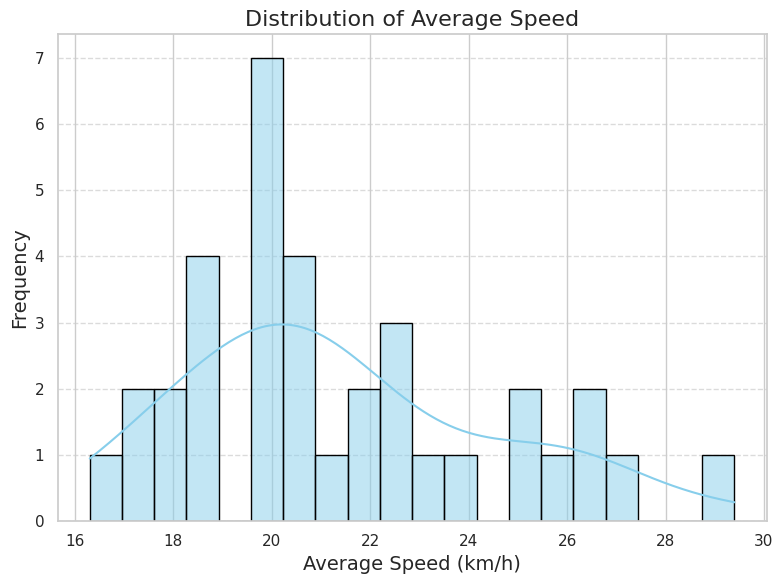

<Figure size 600x500 with 0 Axes>

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))  # Make the figure bigger for clarity

sns.histplot(df['Average Speed'],
             bins=20,       # Number of bins; adjust based on your data
             kde=True,      # Overlay a smooth density curve
             color='skyblue',
             edgecolor='black')

plt.title("Distribution of Average Speed", fontsize=16)
plt.xlabel("Average Speed (km/h)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Optional: add horizontal gridlines
plt.tight_layout()  # Ensures everything fits nicely
plt.show()


/tmp/ipython-input-2656055395.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


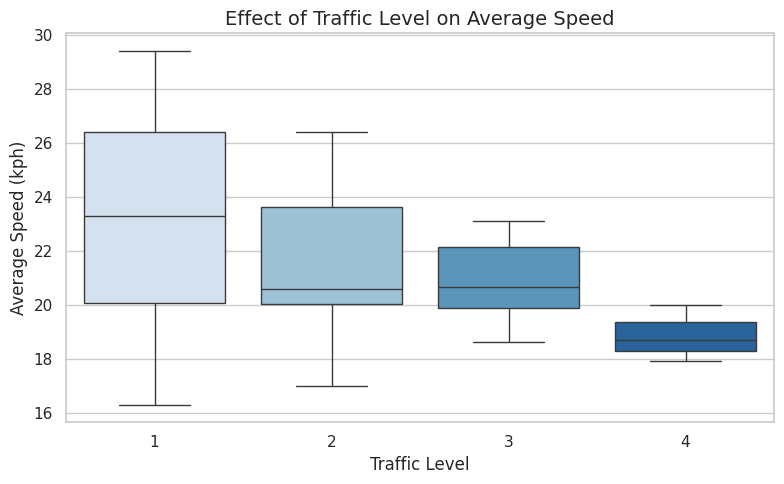

<Figure size 600x500 with 0 Axes>

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.set_style("whitegrid")

sns.boxplot(
    data=df,
    x='Traffic Level',
    y='Average Speed',
    palette='Blues'
)

plt.title("Effect of Traffic Level on Average Speed", fontsize=14)
plt.xlabel("Traffic Level", fontsize=12)
plt.ylabel("Average Speed (kph)", fontsize=12)

plt.tight_layout()
plt.show()
plt.savefig("traffic_vs_speed.png", dpi=300, bbox_inches='tight')


/tmp/ipython-input-3704676085.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


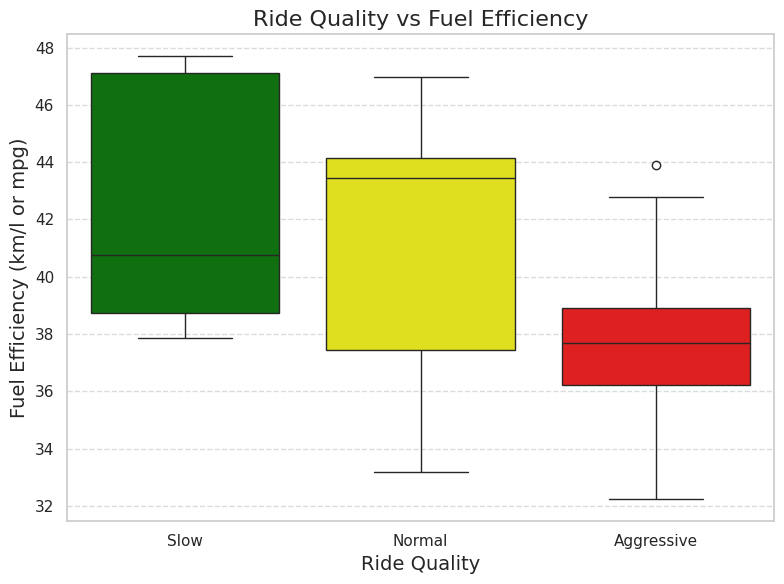

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))  # Bigger figure for clarity

# Color palette for Ride Quality
palette_colors = {'Slow':'green', 'Normal':'yellow', 'Aggressive':'red'}

sns.boxplot(
    data=df,
    x='Ride Quality',
    y='Efficiency',
    order=['Slow', 'Normal', 'Aggressive'],  # custom order
    palette=palette_colors
)

plt.title("Ride Quality vs Fuel Efficiency", fontsize=16)
plt.xlabel("Ride Quality", fontsize=14)
plt.ylabel("Fuel Efficiency (km/l or mpg)", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # optional horizontal grid
plt.tight_layout()
plt.show()



/tmp/ipython-input-1697571697.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


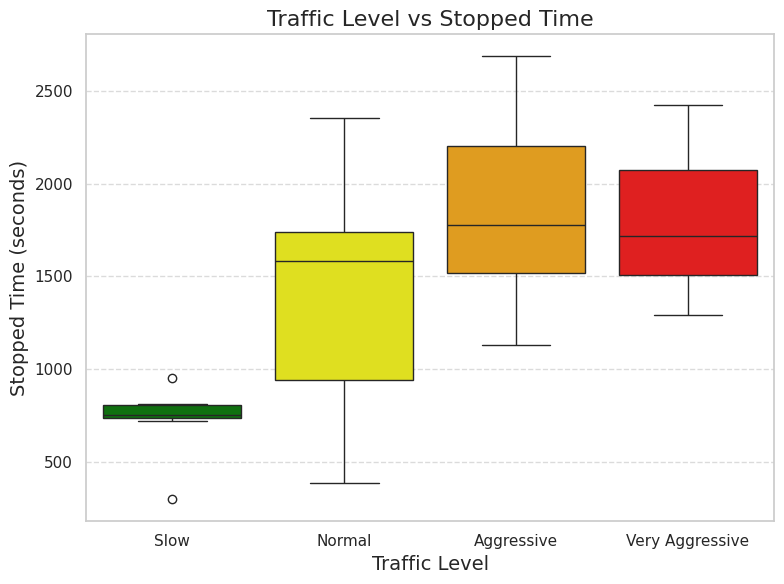

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))  # Bigger figure for clarity

# Map numeric traffic levels to labels
level_labels = {1: 'Slow', 2: 'Normal', 3: 'Aggressive', 4: 'Very Aggressive'}
df['Traffic Level Label'] = df['Traffic Level'].map(level_labels)

# Color palette for traffic levels
palette_colors = {
    'Slow': 'green',
    'Normal': 'yellow',
    'Aggressive': 'orange',
    'Very Aggressive': 'red'
}

# Boxplot
sns.boxplot(
    data=df,
    x='Traffic Level Label',
    y='Stopped Time',
    order=['Slow', 'Normal', 'Aggressive', 'Very Aggressive'],
    palette=palette_colors
)

# Titles and labels
plt.title("Traffic Level vs Stopped Time", fontsize=16)
plt.xlabel("Traffic Level", fontsize=14)
plt.ylabel("Stopped Time (seconds)", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # horizontal grid
plt.tight_layout()
plt.show()


In [50]:
import pandas as pd

# Group by Traffic Level and calculate stats
stats = df.groupby('Traffic Level')['Stopped Time'].agg(['mean', 'median', 'std']).reset_index()

# Optional: round numbers for presentation
stats = stats.round({'mean': 2, 'median': 2, 'std': 2})

# Rename columns for clarity
stats.columns = ['Traffic Level', 'Mean (min)', 'Median (min)', 'SD (min)']

# Display table
print(stats)




   Traffic Level  Mean (min)  Median (min)  SD (min)
0              1      729.50         753.0    187.85
1              2     1364.07        1583.0    598.32
2              3     1827.20        1775.5    501.74
3              4     1813.00        1717.0    572.07


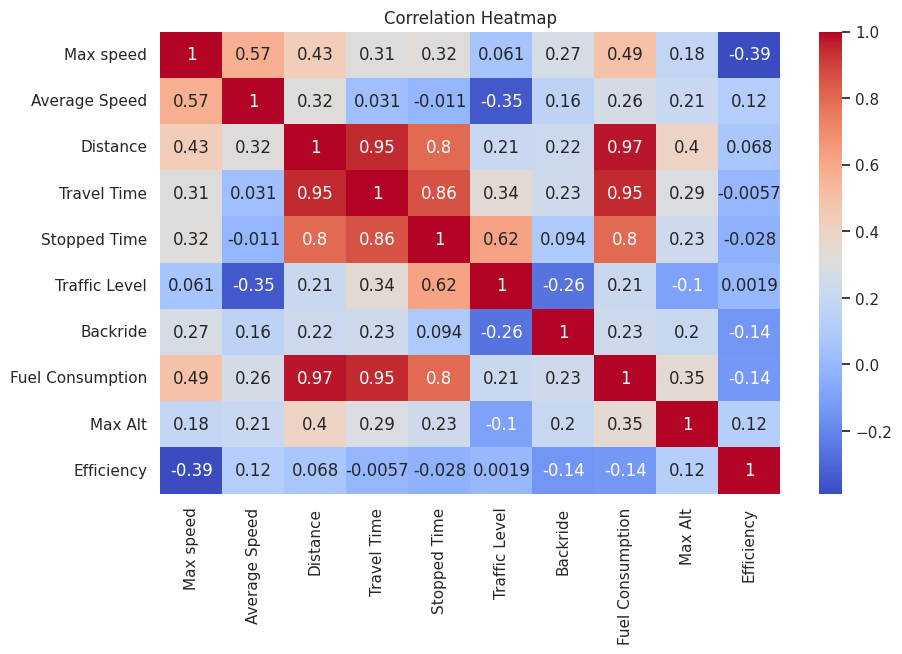

In [11]:
plt.figure()

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()


/tmp/ipython-input-1495471387.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='Ride Quality', y='Fuel Consumption',
/tmp/ipython-input-1495471387.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='Traffic Level', y='Fuel Consumption', palette='coolwarm')
/tmp/ipython-input-1495471387.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='Backride', y='Fuel Consumption', palette=['#b2df8a','#fdae6b'])
/tmp/ipython-input-1495471387.py:60: UserWarning: 
The palette list has fewer values (2)

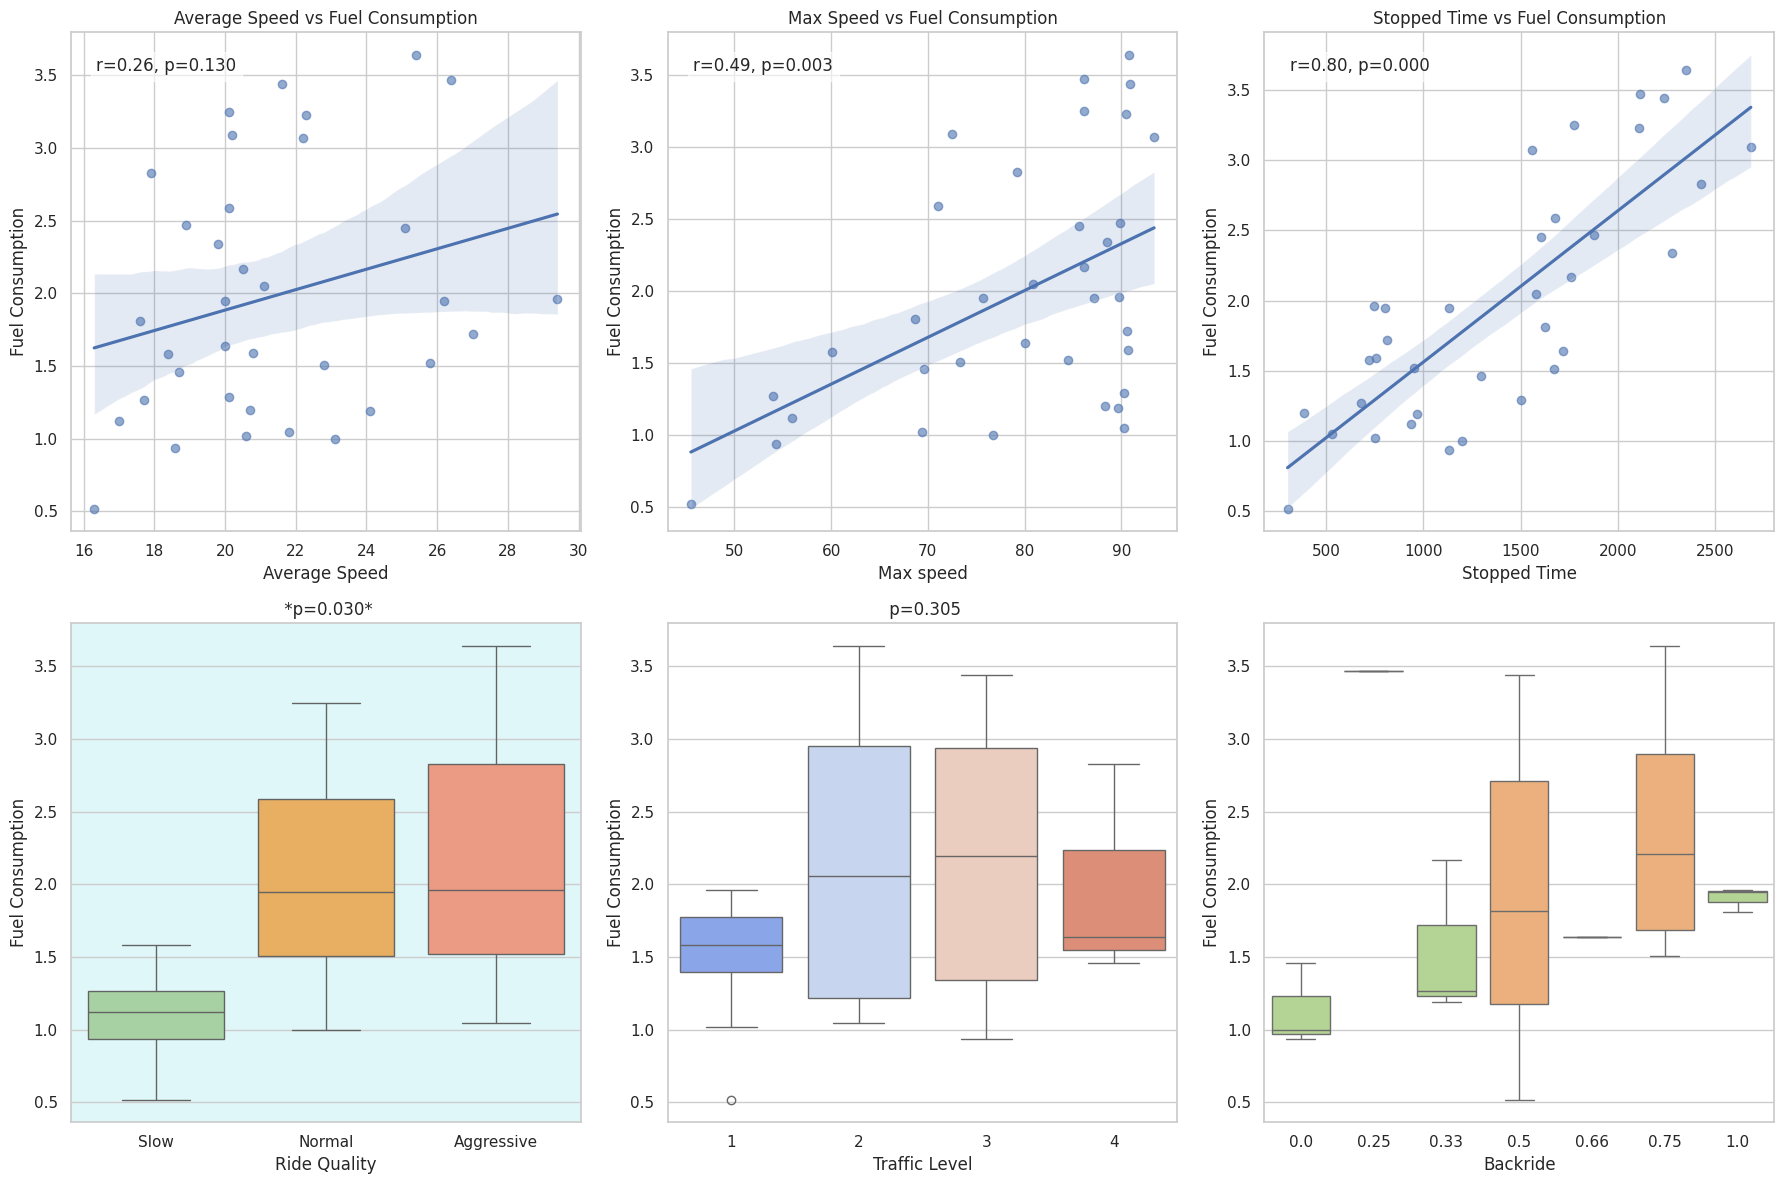

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

sns.set(style="whitegrid")
plt.figure(figsize=(18,12))

# =========================
# 1️⃣ Continuous Variables
# =========================

plt.subplot(2,3,1)
sns.regplot(data=df, x='Average Speed', y='Fuel Consumption', scatter_kws={'alpha':0.6})
plt.title("Average Speed vs Fuel Consumption")
# Highlight correlation
r, p = stats.pearsonr(df['Average Speed'], df['Fuel Consumption'])
plt.text(0.05, 0.95, f"r={r:.2f}, p={p:.3f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6))

plt.subplot(2,3,2)
sns.regplot(data=df, x='Max speed', y='Fuel Consumption', scatter_kws={'alpha':0.6})
plt.title("Max Speed vs Fuel Consumption")
r, p = stats.pearsonr(df['Max speed'], df['Fuel Consumption'])
plt.text(0.05, 0.95, f"r={r:.2f}, p={p:.3f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6))

plt.subplot(2,3,3)
sns.regplot(data=df, x='Stopped Time', y='Fuel Consumption', scatter_kws={'alpha':0.6})
plt.title("Stopped Time vs Fuel Consumption")
r, p = stats.pearsonr(df['Stopped Time'], df['Fuel Consumption'])
plt.text(0.05, 0.95, f"r={r:.2f}, p={p:.3f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6))

# =========================
# 2️⃣ Categorical Variables
# =========================

def highlight_sig(ax, group_col):
    """Highlight boxes with significant ANOVA effect."""
    groups = [group['Fuel Consumption'].values for name, group in df.groupby(group_col)]
    f_stat, p_val = stats.f_oneway(*groups)
    if p_val < 0.05:
        ax.set_facecolor('#e0f7fa')  # light cyan background for significance
        ax.set_title(f"{ax.get_title()} *p={p_val:.3f}*", fontsize=12)
    else:
        ax.set_title(f"{ax.get_title()} p={p_val:.3f}", fontsize=12)

plt.subplot(2,3,4)
ax = sns.boxplot(data=df, x='Ride Quality', y='Fuel Consumption',
            order=['Slow','Normal','Aggressive'],
            palette=['#a1d99b','#feb24c','#fc9272'])  # color for low->high
highlight_sig(ax, 'Ride Quality')

plt.subplot(2,3,5)
ax = sns.boxplot(data=df, x='Traffic Level', y='Fuel Consumption', palette='coolwarm')
highlight_sig(ax, 'Traffic Level')

plt.subplot(2,3,6)
ax = sns.boxplot(data=df, x='Backride', y='Fuel Consumption', palette=['#b2df8a','#fdae6b'])

plt.tight_layout()
plt.show()


/tmp/ipython-input-3739194605.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_speed_eff = df.groupby('AvgSpeed_Group')['Efficiency'] \
/tmp/ipython-input-3739194605.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_speed_eff, x='AvgSpeed_Group', y='Efficiency', palette='coolwarm')


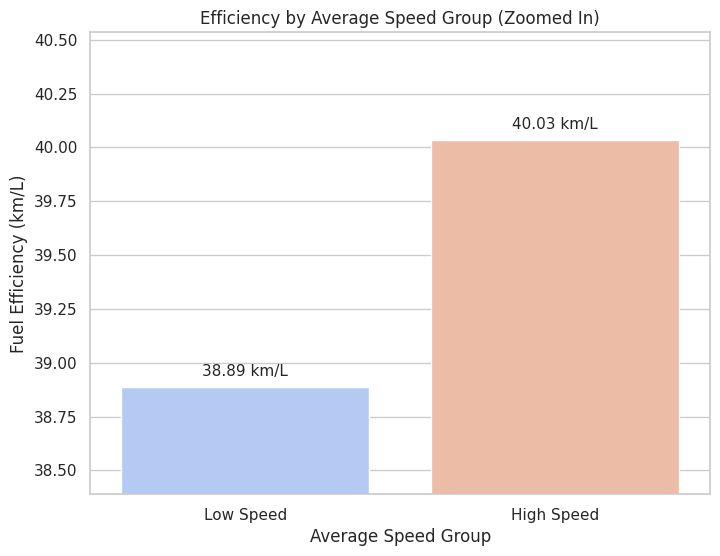

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

# Split into two groups using median
df['AvgSpeed_Group'] = pd.qcut(df['Average Speed'],
                               q=2,
                               labels=['Low Speed', 'High Speed'])

# Compute mean efficiency
avg_speed_eff = df.groupby('AvgSpeed_Group')['Efficiency'] \
                  .mean() \
                  .reset_index() \
                  .sort_values(by='Efficiency', ascending=False)

# Plot
plt.figure()
sns.barplot(data=avg_speed_eff, x='AvgSpeed_Group', y='Efficiency', palette='coolwarm')

# Annotate values
for i, row in avg_speed_eff.iterrows():
    plt.text(i, row.Efficiency + 0.05, f"{row.Efficiency:.2f} km/L", ha='center', fontsize=11)

plt.title("Efficiency by Average Speed Group (Zoomed In)")
plt.ylim(avg_speed_eff['Efficiency'].min() - 0.5, avg_speed_eff['Efficiency'].max() + 0.5)
plt.ylabel("Fuel Efficiency (km/L)")
plt.xlabel("Average Speed Group")
plt.show()


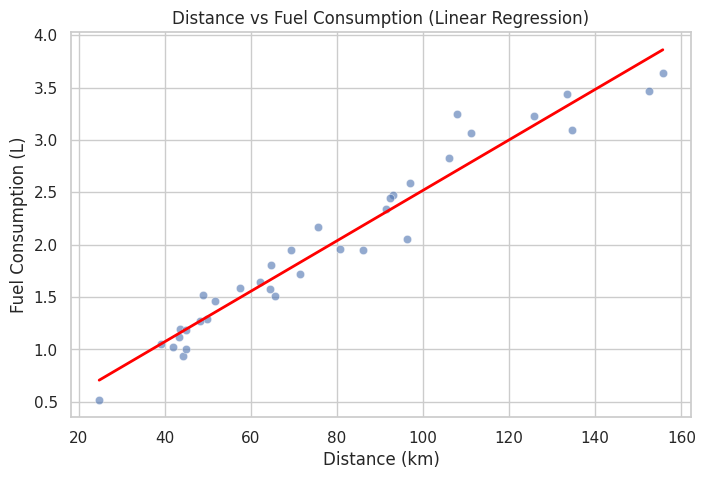

In [14]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape distance for sklearn
X_dist = df[['Distance']]   # must be 2D
y_fuel = df['Fuel Consumption']

# Train model
dist_model = LinearRegression()
dist_model.fit(X_dist, y_fuel)

# Get predictions (sorted for clean line)
sorted_df = df.sort_values('Distance')
X_sorted = sorted_df[['Distance']]
y_pred = dist_model.predict(X_sorted)

# Plot
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['Distance'], y=df['Fuel Consumption'], alpha=0.6)

plt.plot(sorted_df['Distance'], y_pred, color='red', linewidth=2)

plt.title("Distance vs Fuel Consumption (Linear Regression)")
plt.xlabel("Distance (km)")
plt.ylabel("Fuel Consumption (L)")
plt.grid(True)

plt.show()


In [15]:
df['km_per_L'] = df['Distance'] / df['Fuel Consumption']

df[['Distance', 'Fuel Consumption', 'km_per_L']].head()


,Distance,Fuel Consumption,km_per_L
0,43.6,1.20,36.333333
1,39.2,1.05,37.333333
2,44.3,0.94,47.127660
3,80.8,1.96,41.224490
4,43.4,1.12,38.750000


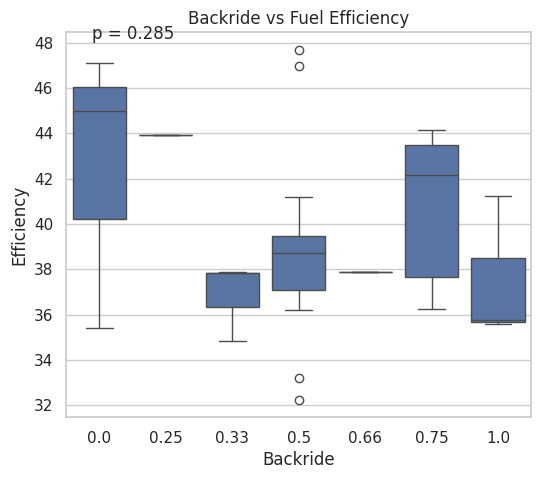

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.figure(figsize=(6,5))

# Boxplot
sns.boxplot(data=df, x='Backride', y='Efficiency')
plt.title("Backride vs Fuel Efficiency")

# Calculate p-value (two-sample t-test)
group0 = df[df['Backride'] == 0]['Efficiency']
group1 = df[df['Backride'] == 1]['Efficiency']

t_stat, p_val = stats.ttest_ind(group0, group1)

# Annotate p-value
plt.text(0.5, df['Efficiency'].max() + 0.5, f"p = {p_val:.3f}",
         ha='center', fontsize=12)

plt.show()


In [17]:
df['Backride_binary'] = df['Backride'].apply(
    lambda x: 0 if x in [0, 0.25] else 1
)


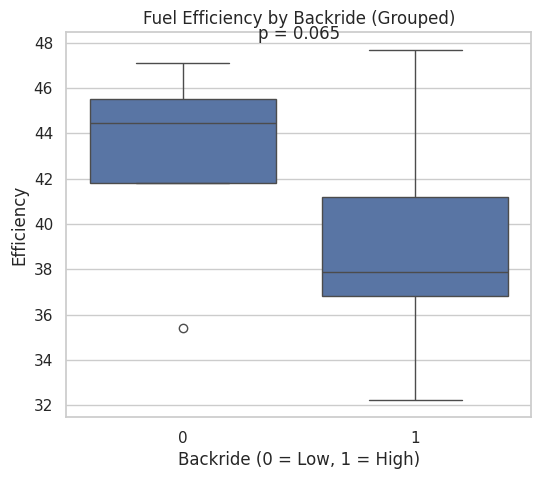

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.figure(figsize=(6,5))

# Boxplot
sns.boxplot(data=df, x='Backride_binary', y='Efficiency')
plt.title("Fuel Efficiency by Backride (Grouped)")
plt.xlabel("Backride (0 = Low, 1 = High)")

# Calculate p-value (two-sample t-test)
group0 = df[df['Backride_binary'] == 0]['Efficiency']
group1 = df[df['Backride_binary'] == 1]['Efficiency']

t_stat, p_val = stats.ttest_ind(group0, group1)

# Annotate p-value
plt.text(0.5, df['Efficiency'].max() + 0.5, f"p = {p_val:.3f}",
         ha='center', fontsize=12)

plt.show()


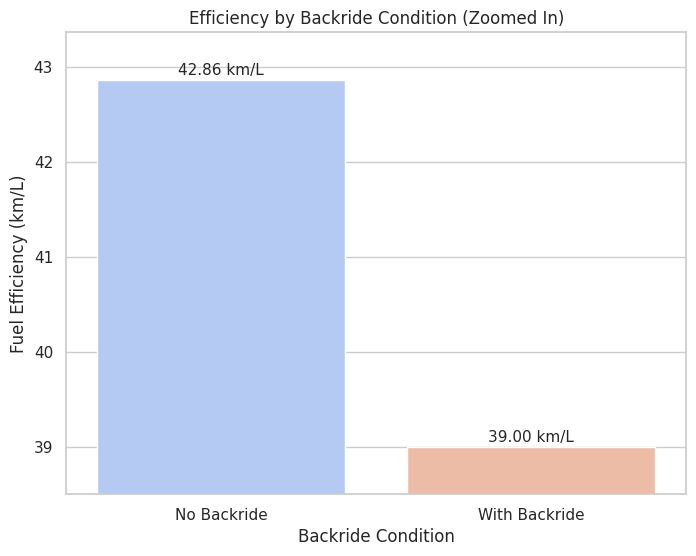

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

# Compute mean efficiency by backride
backride_eff = df.groupby('Backride_binary')['Efficiency'] \
                  .mean() \
                  .reset_index() \
                  .sort_values(by='Efficiency', ascending=False)

# Optional: Rename for better labels
backride_eff['Backride_binary'] = backride_eff['Backride_binary'].map({
    0: 'No Backride',
    1: 'With Backride'
})

# Plot
plt.figure()
sns.barplot(data=backride_eff,
            x='Backride_binary',
            y='Efficiency',
            palette='coolwarm',
            hue='Backride_binary',
            legend=False)

# Annotate values
for i, row in backride_eff.iterrows():
    plt.text(i, row.Efficiency + 0.05,
             f"{row.Efficiency:.2f} km/L",
             ha='center', fontsize=11)

plt.title("Efficiency by Backride Condition (Zoomed In)")
plt.ylim(backride_eff['Efficiency'].min() - 0.5,
         backride_eff['Efficiency'].max() + 0.5)
plt.ylabel("Fuel Efficiency (km/L)")
plt.xlabel("Backride Condition")
plt.show()


In [20]:
df.groupby('Backride_binary')['Fuel Consumption'].mean()


,Fuel Consumption
Backride_binary,
0,1.717500
1,2.016452


In [21]:
df_encoded = pd.get_dummies(df,
                            columns=['Ride Quality', 'Traffic Level', 'Backride_binary'],
                            )
# Convert True/False to 1/0
#df_encoded = df_encoded.astype(int, errors='ignore')



In [22]:
#numeric_df = df_encoded.select_dtypes(include=np.number)

#plt.figure(figsize=(20,15))
#sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
#plt.title("Correlation Heatmap Including Categorical Variables")
#plt.show()


In [23]:
df_encoded.columns

Index(['Date', 'Max speed', 'Average Speed', 'Distance', 'Travel Time',
       'Stopped Time', 'Backride', 'Fuel Consumption', 'Max Alt', 'Efficiency',
       'AvgSpeed_Group', 'km_per_L', 'Ride Quality_Aggressive',
       'Ride Quality_Normal', 'Ride Quality_Slow', 'Traffic Level_1',
       'Traffic Level_2', 'Traffic Level_3', 'Traffic Level_4',
       'Backride_binary_0', 'Backride_binary_1'],
      dtype='object')

In [24]:
#from sklearn.linear_model import LinearRegression
#import pandas as pd

# Make a copy
#df_scaled = df_encoded.copy()

# Rescale stopped time to minutes
#df_scaled['Stopped Time'] = df_scaled['Stopped Time']

# Keep travel time in minutes
#df_scaled['Travel Time'] = df_scaled['Travel Time'] / 60




In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Numeric and categorical columns
numeric_features = [
    'Distance',
    'Average Speed',
    'Max speed',
    'Travel Time',
    'Stopped Time',
]

categorical_features = [
    'Ride Quality',
    'Backride_binary'
]

X = df[numeric_features + categorical_features]
y = df['Fuel Consumption']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing with normalization for numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Normalize numeric features
        ('cat', OneHotEncoder(drop='first'), categorical_features)  # OneHotEncoding for categorical features
    ]
)

# Define the pipeline with Ridge regression (or Lasso)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))  # You can adjust alpha to control regularization strength
])

# Train the model
pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = pipeline.predict(X_test)

# Evaluate the model performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print the results
print("Model Evaluation Metrics (Ridge Regularization):")
print(f"R² Score: {r2:.3f}")
print(f"MAE: {mae:.3f} L")  # MAE in Liters
print(f"RMSE: {rmse:.3f} L")  # RMSE in Liters


Model Evaluation Metrics (Ridge Regularization):
R² Score: 0.960
MAE: 0.111 L
RMSE: 0.138 L


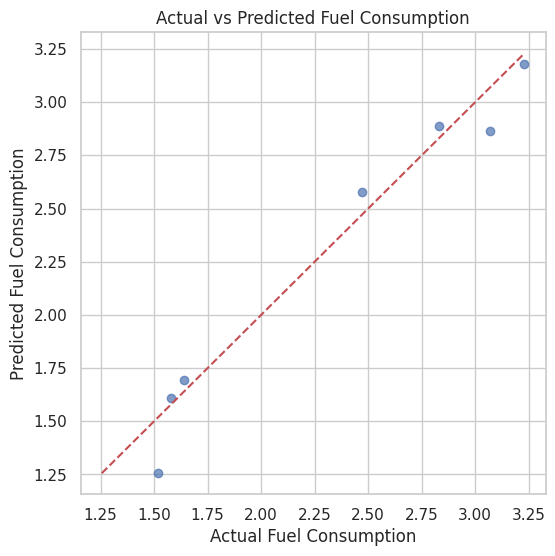

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual Fuel Consumption")
plt.ylabel("Predicted Fuel Consumption")
plt.title("Actual vs Predicted Fuel Consumption")

plt.grid(True)
plt.show()


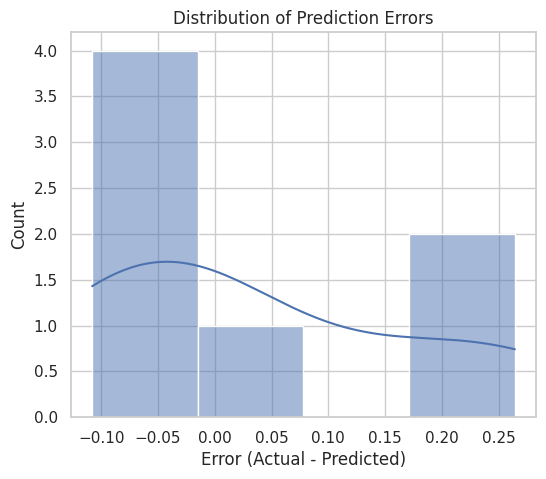

In [27]:
import seaborn as sns
residuals = y_test - y_pred
plt.figure(figsize=(6,5))
sns.histplot(residuals, kde=True)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Error (Actual - Predicted)")
plt.show()


In [28]:
import pandas as pd

# get feature names after preprocessing
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# get coefficients
coefficients = pipeline.named_steps['model'].coef_

# create dataframe
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# sort by importance
coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)

print(coef_df.head(10))


                    Feature  Coefficient
0             num__Distance     0.402991
3          num__Travel Time     0.380561
2            num__Max speed     0.089812
5  cat__Ride Quality_Normal    -0.065075
6    cat__Ride Quality_Slow    -0.039775
7    cat__Backride_binary_1     0.026368
4         num__Stopped Time     0.007226
1        num__Average Speed     0.006905


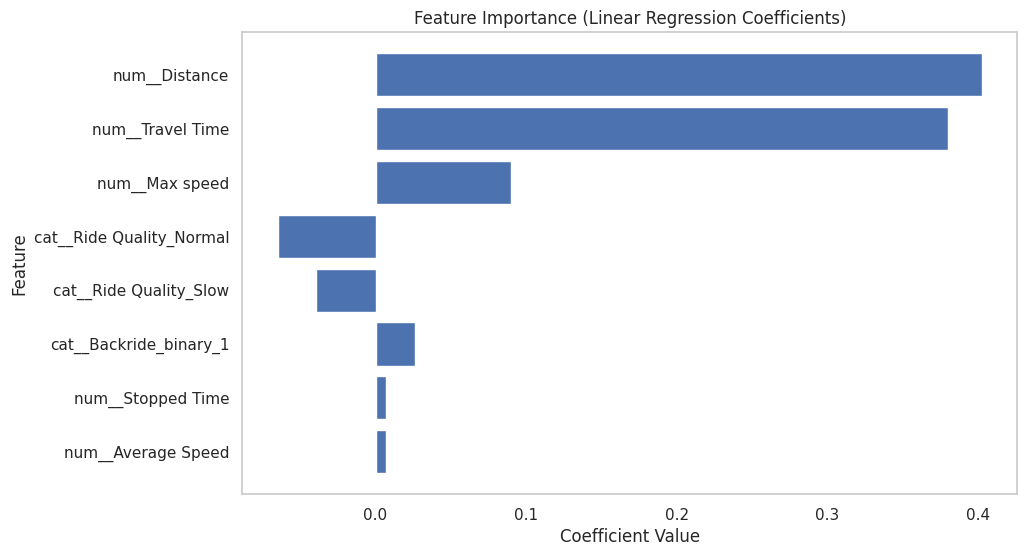

In [29]:
import matplotlib.pyplot as plt

# top 15 most important features
top_n = 15
coef_top = coef_df.head(top_n)

plt.figure(figsize=(10,6))
plt.barh(coef_top['Feature'], coef_top['Coefficient'])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.gca().invert_yaxis()
plt.grid()
plt.show()


In [30]:
import pandas as pd

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# clean names
coef_df['Feature'] = coef_df['Feature'].str.replace('num__', '', regex=False)
coef_df['Feature'] = coef_df['Feature'].str.replace('cat__', '', regex=False)

coef_df.head()



,Feature,Coefficient
0,Distance,0.402991
1,Average Speed,0.006905
2,Max speed,0.089812
3,Travel Time,0.380561
4,Stopped Time,0.007226


/tmp/ipython-input-1488414571.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stopped_eff = df.groupby('Stopped_Group')['Efficiency'] \
/tmp/ipython-input-1488414571.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stopped_eff, x='Stopped_Group', y='Efficiency', palette='coolwarm')


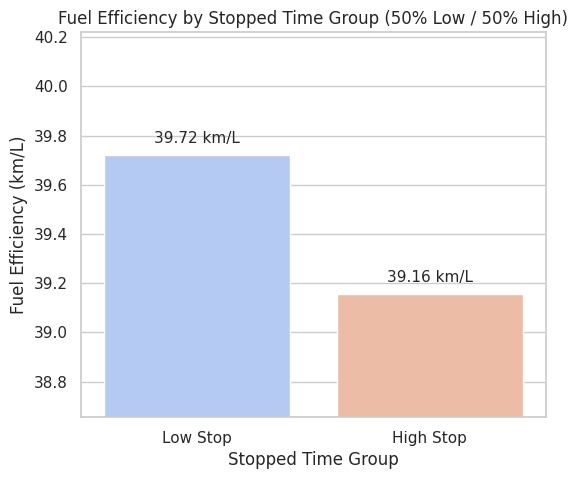

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (6,5)

# Create two groups based on median of Stopped Time
df['Stopped_Group'] = pd.qcut(df['Stopped Time'],
                              q=2,
                              labels=['Low Stop', 'High Stop'])

# Compute mean efficiency for each group
stopped_eff = df.groupby('Stopped_Group')['Efficiency'] \
                 .mean() \
                 .reset_index() \
                 .sort_values(by='Efficiency', ascending=False)

# Plot
plt.figure()
sns.barplot(data=stopped_eff, x='Stopped_Group', y='Efficiency', palette='coolwarm')

# Annotate values
for i, row in stopped_eff.iterrows():
    plt.text(i, row.Efficiency + 0.05, f"{row.Efficiency:.2f} km/L", ha='center', fontsize=11)

plt.title("Fuel Efficiency by Stopped Time Group (50% Low / 50% High)")
plt.ylabel("Fuel Efficiency (km/L)")
plt.xlabel("Stopped Time Group")
plt.ylim(stopped_eff['Efficiency'].min() - 0.5, stopped_eff['Efficiency'].max() + 0.5)
plt.show()


In [32]:
numeric_keywords = [
    'Distance',
    'Average Speed',
    'Max speed',
    'Travel Time',
    'Stopped Time'
]

numeric_coef = coef_df[
    coef_df['Feature'].str.contains('|'.join(numeric_keywords))
]
categorical_coef = coef_df.drop(numeric_coef.index)

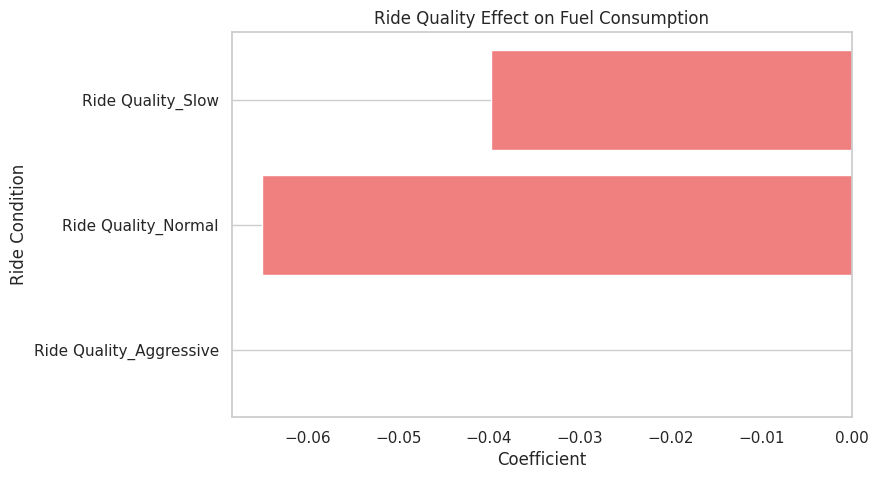

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter Ride Quality coefficients
ride_coef = categorical_coef[
    categorical_coef['Feature'].str.contains('Ride Quality')
].copy()

# Add baseline row for the first category (e.g., 'Ride Quality_0')
baseline = pd.DataFrame({
    'Feature': ['Ride Quality_Aggressive'],
    'Coefficient': [0.0]
})
ride_coef = pd.concat([baseline, ride_coef], ignore_index=True)

# Plot
plt.figure(figsize=(8,5))
plt.barh(ride_coef['Feature'], ride_coef['Coefficient'], color='lightcoral')
plt.title("Ride Quality Effect on Fuel Consumption")
plt.xlabel("Coefficient")
plt.ylabel("Ride Condition")
plt.grid(axis='x')
plt.show()


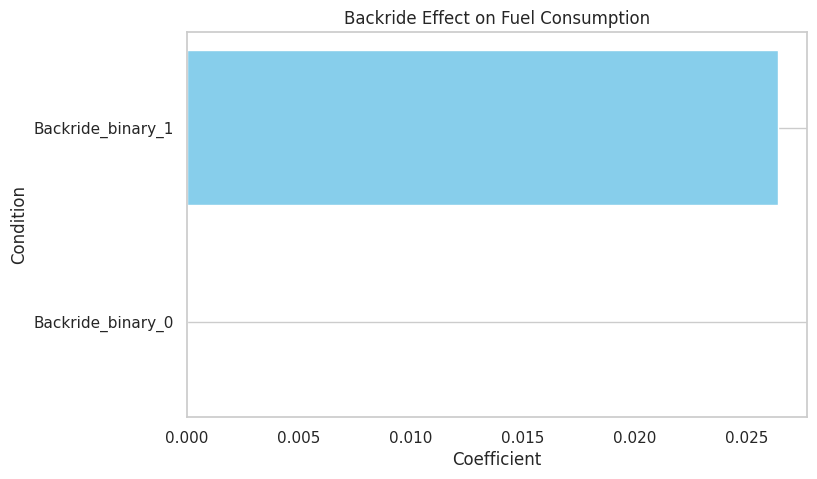

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter Backride coefficients
traffic_coef = categorical_coef[
    categorical_coef['Feature'].str.contains('Backride_binary')
].copy()

# Add baseline row for Backride_binary = 0
baseline = pd.DataFrame({
    'Feature': ['Backride_binary_0'],
    'Coefficient': [0.0]
})
traffic_coef = pd.concat([baseline, traffic_coef], ignore_index=True)

# Plot
plt.figure(figsize=(8,5))
plt.barh(traffic_coef['Feature'], traffic_coef['Coefficient'], color='skyblue')
plt.title("Backride Effect on Fuel Consumption")
plt.xlabel("Coefficient")
plt.ylabel("Condition")
plt.grid(axis='x')
plt.show()


In [35]:
import pandas as pd
import numpy as np

# Define a baseline set of values for the features (for simplicity, use the mean values of the numeric features)
baseline_features = {
    'Distance': df['Distance'].mean(),
    'Average Speed': df['Average Speed'].mean(),
    'Max speed': df['Max speed'].mean(),
    'Travel Time': df['Travel Time'].mean(),
    'Stopped Time': df['Stopped Time'].mean(),
    'Backride_binary': 0  # Assuming no backride as default (0 or 1 depending on your encoding)
}

# Create a dictionary for each ride quality scenario
ride_qualities = ['Slow', 'Normal', 'Aggressive']

# List to store the predictions for each ride quality
predictions = {}

# Iterate over the ride qualities and make predictions
for ride_quality in ride_qualities:
    # Create a copy of the baseline features with the current ride quality
    baseline_features_copy = baseline_features.copy()
    baseline_features_copy['Ride Quality'] = ride_quality

    # Convert the feature dictionary into a DataFrame to pass to the model
    X_baseline = pd.DataFrame([baseline_features_copy])

    # Make a prediction using the trained pipeline
    fuel_consumption = pipeline.predict(X_baseline)

    # Store the result
    predictions[ride_quality] = fuel_consumption[0]

# Print out the predicted fuel consumption for each ride quality
for ride_quality, fuel_consumption in predictions.items():
    print(f"Predicted Fuel Consumption for {ride_quality} Ride Quality: {fuel_consumption:.3f} L")

# Calculate percentage differences between the ride qualities
def percentage_diff(old, new):
    return ((new - old) / old) * 100

# Calculate the percentage differences
normal_vs_slow_pct = percentage_diff(predictions['Slow'], predictions['Normal'])
aggressive_vs_normal_pct = percentage_diff(predictions['Normal'], predictions['Aggressive'])
aggressive_vs_slow_pct = percentage_diff(predictions['Slow'], predictions['Aggressive'])

# Print the percentage differences
print(f"\nPercentage Difference in Fuel Consumption (Normal vs Slow): {normal_vs_slow_pct:.2f}%")
print(f"Percentage Difference in Fuel Consumption (Aggressive vs Normal): {aggressive_vs_normal_pct:.2f}%")
print(f"Percentage Difference in Fuel Consumption (Aggressive vs Slow): {aggressive_vs_slow_pct:.2f}%")


Predicted Fuel Consumption for Slow Ride Quality: 1.934 L
Predicted Fuel Consumption for Normal Ride Quality: 1.909 L
Predicted Fuel Consumption for Aggressive Ride Quality: 1.974 L

Percentage Difference in Fuel Consumption (Normal vs Slow): -1.31%
Percentage Difference in Fuel Consumption (Aggressive vs Normal): 3.41%
Percentage Difference in Fuel Consumption (Aggressive vs Slow): 2.06%


In [36]:
import pandas as pd

def predict_fuel(distance, avg_speed, max_speed, travel_time, stopped_time,
                 ride_quality, backride):
    """
    Predict fuel consumption based on input features.

    Parameters:
    - distance (float): distance traveled (km)
    - avg_speed (float): average speed (km/h)
    - max_speed (float): maximum speed (km/h)
    - travel_time (float): travel time (minutes or hours as used in df)
    - stopped_time (float): stopped time (same unit as df)
    - ride_quality (str): e.g., 'Slow', 'Normal', 'Aggressive'
    - traffic_level (int): e.g., 1,2,3,...
    - backride (int): 0 or 1
    """
    # build input dataframe
    input_df = pd.DataFrame({
        'Distance': [distance],
        'Average Speed': [avg_speed],
        'Max speed': [max_speed],
        'Travel Time': [travel_time],
        'Stopped Time': [stopped_time],
        'Ride Quality': [ride_quality],
        'Backride_binary': [backride]
    })

    # predict
    fuel_pred = pipeline.predict(input_df)[0]
    return fuel_pred

# Example usage:
predicted_fuel = predict_fuel(
    distance=46,
    avg_speed=20.6,
    max_speed=90.8,
    travel_time=129,
    stopped_time=631,
    ride_quality='Aggressive',
    backride=1
)

predicted_fuel1 = predict_fuel(
    distance=46,
    avg_speed=19.5,
    max_speed=66,
    travel_time=133,
    stopped_time=690,
    ride_quality='Normal',
    backride=1
)

predicted_fuel2 = predict_fuel(
    distance=46,
    avg_speed=20.6,
    max_speed=90.8,
    travel_time=129,
    stopped_time=631,
    ride_quality='Aggressive',
    backride=1
)

predicted_fuel3 = predict_fuel(
    distance=46,
    avg_speed=20.6,
    max_speed=90.8,
    travel_time=129,
    stopped_time=631,
    ride_quality='Aggressive',
    backride=0
)

predicted_fuel4 = predict_fuel(
    distance=46,
    avg_speed=20,
    max_speed=66,
    travel_time=123,
    stopped_time=590,
    ride_quality='Normal',
    backride=0
)


print(f"Predicted Fuel Consumption Aggressive: {predicted_fuel:.3f} L")
print(f"Predicted Fuel Consumption Normal: {predicted_fuel1:.3f} L")
print()
print(f"Predicted Fuel Consumption with Backride: {predicted_fuel2:.3f} L")
print(f"Predicted Fuel Consumption with no Backride: {predicted_fuel3:.3f} L")
print()
print(f"Predicted Fuel Consumption with optimal riding stats: {predicted_fuel4:.3f} L")


Predicted Fuel Consumption Aggressive: 1.356 L
Predicted Fuel Consumption Normal: 1.137 L

Predicted Fuel Consumption with Backride: 1.356 L
Predicted Fuel Consumption with no Backride: 1.329 L

Predicted Fuel Consumption with optimal riding stats: 1.065 L
